In [15]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage
import os
import requests
import polyline

load_dotenv()

ORS_API_KEY = os.getenv("OPENROUTESERVICE_KEY")
OCM_API_KEY = os.getenv("OPENCHARGEMAP_KEY")

llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

In [16]:
class TripDetails(BaseModel):
    origin: str | None = Field(default=None, description="Source or origin of the trip")

    destination: str | None = Field(default=None, description="Destination of the trip")

    battery_percentage_on_departure: int | None = Field(
        default=None,
        ge=0,
        le=100,
        description="Battery percentage of the car at departure",
    )

    is_round_trip: bool | None = Field(
        default=None, description="Whether the trip is a round trip"
    )


class LLMMessage(BaseModel):
    message: str

In [17]:
# state
class TripState(TypedDict):
    trip: TripDetails
    messages: list
    trip_ready: bool

In [18]:
structured_llm_1 = llm.with_structured_output(TripDetails)
structured_llm_2 = llm.with_structured_output(LLMMessage)

In [ ]:
def extract_trip_details(state: TripState):

    prompt = f"""
        Extract the trip details from the conversation.
        If the user's response is ambiguous or unclear, do not extract the information.
        Do not overwrite existing values with `None`. Preserve previously collected information unless the user explicitly changes it.

        Current Trip:
        {state["trip"]}

        Conversation:
        {state["messages"]}

    """
    trip_details = structured_llm_1.invoke(prompt)

    return {"trip": trip_details}


def gather_trip_details(state: TripState):

    prompt = f"""
        You are an intelligent EV trip-planning assistant.
        
        Current Trip:
        {state["trip"]}

        Conversation:
        {state["messages"]}

        
        Have a natural conversation with the user.

        If any required trip information is missing, ask the user, but only one question at a time.

        If the user has not decided where to go, help them decide.

        If the user's response is ambiguous or unclear, ask a follow-up question to clarify before proceeding. Do not make assumptions.

        Do not mention internal fields or technical details.
        Do not answer anything unrelated to EV trip planning.

    """

    response = structured_llm_2.invoke(prompt)

    return {"messages": [AIMessage(content=response.message)]}


def validate_trip_details(state: TripState):

    trip = state["trip"]

    trip_ready = all(
        [
            trip.origin is not None,
            trip.destination is not None,
            trip.battery_percentage_on_departure is not None,
            trip.is_round_trip is not None,
        ]
    )

    return {"trip_ready": trip_ready}


def router_trip_details(
    state: TripState,
) -> Literal["gather_trip_details", "find_route"]:

    if state["trip_ready"]:
        print("Trip details gathered!")
        return "find_route"

    return "gather_trip_details"


def get_coordinates(place_name: str):
    url = "https://api.openrouteservice.org/geocode/search"

    headers = {"Authorization": ORS_API_KEY}

    params = {"text": place_name, "size": 1}

    response = requests.get(url, headers=headers, params=params, timeout=10)

    response.raise_for_status()

    data = response.json()

    if not data.get("features"):
        return None

    coordinates = data["features"][0]["geometry"]["coordinates"]

    return coordinates[0], coordinates[1]


def get_route(origin: str, destination: str):
    start = get_coordinates(origin)
    end = get_coordinates(destination)

    if start is None or end is None:
        return None

    url = "https://api.openrouteservice.org/v2/directions/driving-car"

    headers = {"Authorization": ORS_API_KEY, "Content-Type": "application/json"}

    body = {"coordinates": [start, end]}

    response = requests.post(url, headers=headers, json=body, timeout=20)

    response.raise_for_status()

    data = response.json()

    route = data["routes"][0]

    return {
        "distance_km": round(route["summary"]["distance"] / 1000, 2),
        "duration_minutes": round(route["summary"]["duration"] / 60, 1),
        "geometry": route["geometry"],
    }


def get_charging_stations_along_route(
    geometry: str, sample_interval: int = 30, search_radius_km: int = 10
):
    # polyline.decode returns tuples of (latitude, longitude)
    coordinates = polyline.decode(geometry)

    if not coordinates:
        return []

    sampled_coordinates = coordinates[::sample_interval]

    if coordinates[-1] not in sampled_coordinates:
        sampled_coordinates.append(coordinates[-1])

    stations = {}
    url = "https://api.openchargemap.io/v3/poi/"
    headers = {"X-API-Key": OCM_API_KEY, "User-Agent": "EV-Trip_Planner"}

    for lat, lon in sampled_coordinates:
        params = {
            "latitude": lat,
            "longitude": lon,
            "distance": search_radius_km,
            "distanceunit": "KM",
            "maxresults": 20,
            "compact": True,
        }

        response = requests.get(url, headers=headers, params=params, timeout=15)

        if response.status_code != 200:
            continue

        for station in response.json():
            station_id = station.get("ID")
            if not station_id:
                continue

            address = station.get("AddressInfo", {})

            stations[station_id] = {
                "id": station_id,
                "name": address.get("Title"),
                "latitude": address.get("Latitude"),
                "longitude": address.get("Longitude"),
                "town": address.get("Town"),
                "state": address.get("StateOrProvince"),
                "address": address.get("AddressLine1"),
            }

    return list(stations.values())


def find_route(state: TripState):

    trip = state["trip"]

    route = get_route(trip.origin, trip.destination)

    if route is None:
        return {
            "messages": [
                AIMessage(content="I couldn't find a route between those locations.")
            ]
        }

    stations = get_charging_stations_along_route(route["geometry"])

    message = (
        f"I found a route for your trip.\n\n"
        f"Distance: {route['distance_km']} km\n"
        f"Estimated travel time: {route['duration_minutes']} minutes\n"
        f"Charging stations found along the route: {len(stations)}"
    )
    print(message)
    print(stations)

    return {"messages": [AIMessage(content=message)]}

In [20]:
graph = StateGraph(TripState)

graph.add_node("gather_trip_details", gather_trip_details)
graph.add_node("extract_trip_details", extract_trip_details)
graph.add_node("validate_trip_details", validate_trip_details)
graph.add_node("find_route", find_route)

In [21]:
graph.add_edge(START, "gather_trip_details")
graph.add_edge("gather_trip_details", "extract_trip_details")
graph.add_edge("extract_trip_details", "validate_trip_details")
graph.add_conditional_edges("validate_trip_details", router_trip_details)
graph.add_edge("find_route", END)

In [22]:
app = graph.compile()


In [23]:
state = {"trip": TripDetails(), "messages": [], "trip_ready": False}

# while True:

#     user_input = input("\nYou: ")

#     if user_input.lower() in ["exit", "quit"]:
#         break

#     state["messages"].append(HumanMessage(content=user_input))

#     state = app.invoke(state)

#     ai_message = state["messages"][-1]

#     print(f"AI: {ai_message.content}")

#     if state["trip_ready"]:
#         print("\nTrip details collected.")
#         print(state["trip"])
#         break

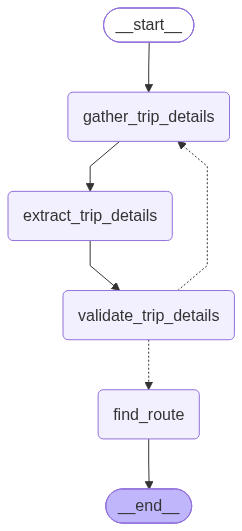

In [24]:
app